total de linhas de apenas: (2197234, 69)
------------------------------------------------------------
qtde de inscritos:


,situacao_fies,qtde_inscritos
0,CONTRATADA,160369
1,INSCRIÇÃO POSTERGADA,2324
2,LISTA DE ESPERA,740698
3,NÃO CONTRATADO,1024604
4,OPÇÃO NÃO CONTRATADA,139469
5,PARTICIPACAO CANCELADA PELO CANDIDATO,111202
6,PRÉ-SELECIONADO,12923
7,REJEITADA PELA CPSA,5645


--- Quantidade de NaNs por coluna ---
renda_per_capita                                                                                                             0
gap                                                                                                                          1
idade                                                                                                                        0
nota_corte_gp                                                                                                                0
renda_gap                                                                                                                    1
beneficiado_creduc_fies_NÃO                                                                                                  0
beneficiado_creduc_fies_SIM                                                                                                  0
modalidade_fies_Modalidade II                                            

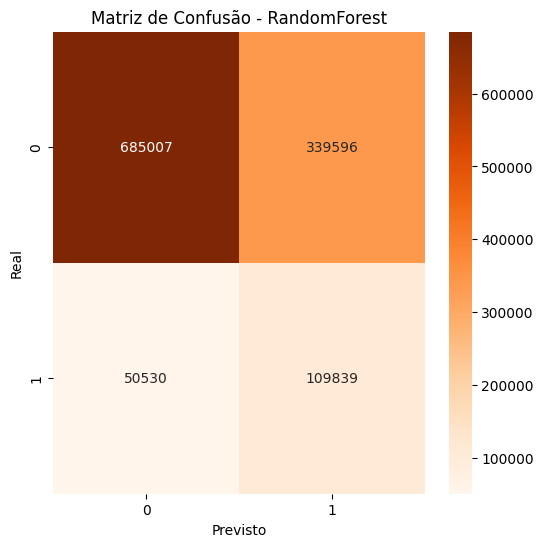

Taxa prevista pelo modelo: 0.379
Taxa real na base: 0.135
Top variáveis mais importantes:


,Variavel,Importancia
0,renda_per_capita,0.225565
1,renda_gap,0.140621
2,gap,0.097785
3,nota_corte_gp,0.072514
4,"subarea_conhecimento_ODONTOLOGIA, QUIROPRAXIA,...",0.069887
5,idade,0.057457
6,conceito_curso_gp_5,0.046048
7,ensino_medio_escola_publica_SIM,0.034847
8,"subarea_conhecimento_DIREITO, COMÉRCIO EXTERIO...",0.025092
9,subarea_conhecimento_MEDICINA VETERINÁRIA,0.018671


Todas as importâncias:


,Variavel,Importancia
0,renda_per_capita,2.255650e-01
1,renda_gap,1.406212e-01
2,gap,9.778526e-02
3,nota_corte_gp,7.251434e-02
4,"subarea_conhecimento_ODONTOLOGIA, QUIROPRAXIA,...",6.988694e-02
5,idade,5.745727e-02
6,conceito_curso_gp_5,4.604793e-02
7,ensino_medio_escola_publica_SIM,3.484663e-02
8,"subarea_conhecimento_DIREITO, COMÉRCIO EXTERIO...",2.509204e-02
9,subarea_conhecimento_MEDICINA VETERINÁRIA,1.867142e-02


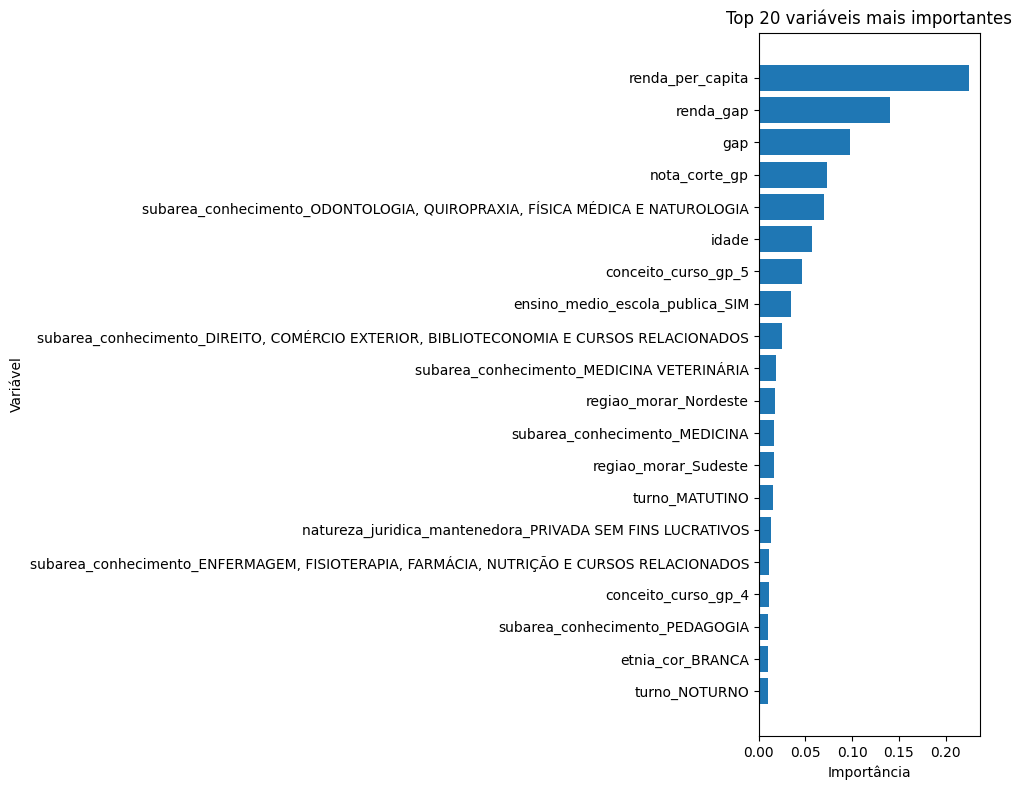


[INFO] Gráfico 1: impacto da NOTA dependendo da RENDA
[INFO] Cada linha fixa uma renda e mostra como a probabilidade varia com o gap
[INFO] Linha azul (0.5 = 50%) é o limiar de decisão do modelo


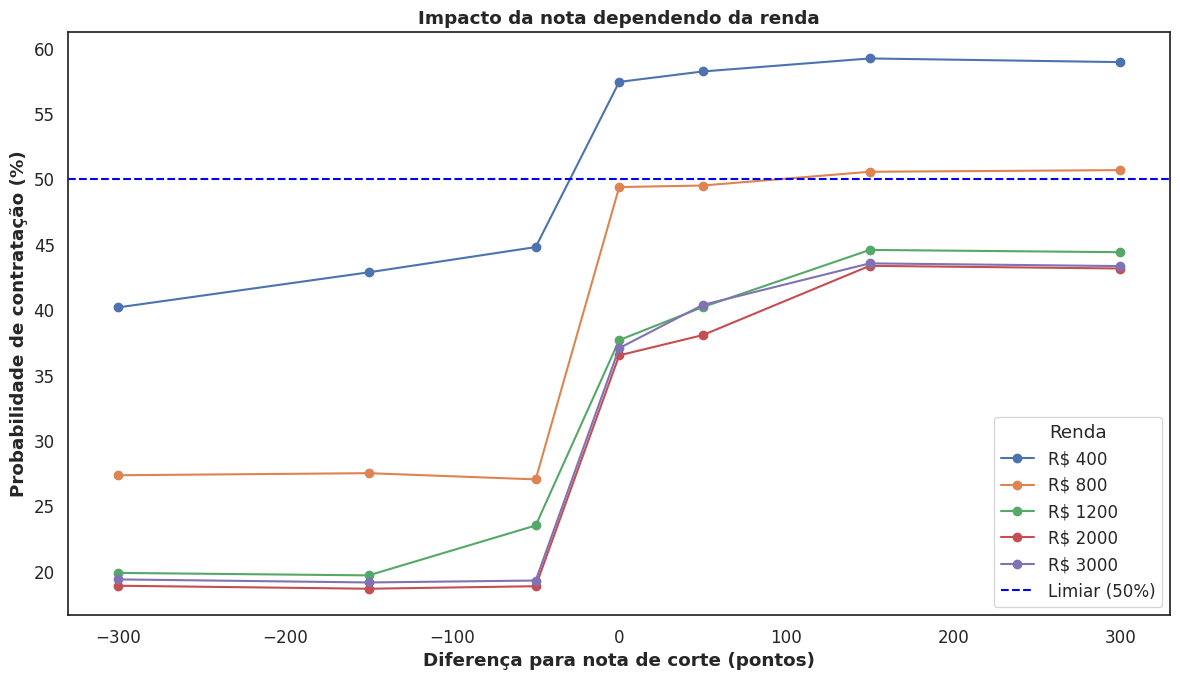


[INFO] Gráfico 2: impacto da RENDA dependendo da NOTA
[INFO] Cada linha fixa um gap e mostra como a probabilidade varia com a renda


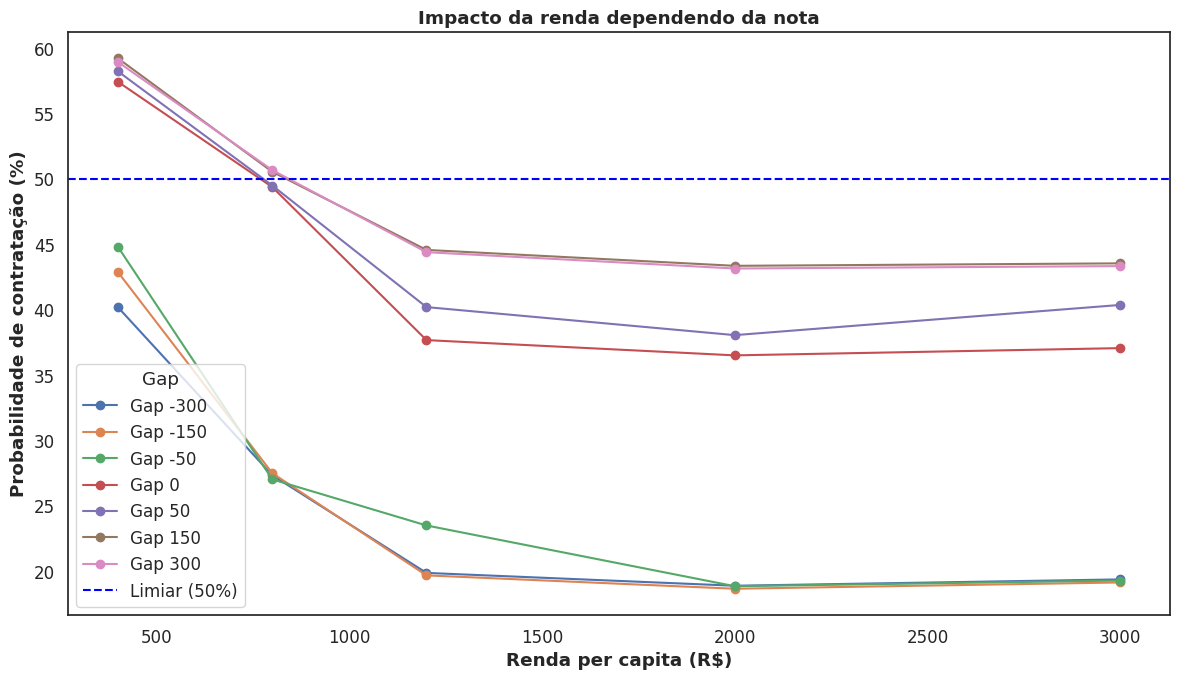


[INFO] Heatmap: visão consolidada renda × nota


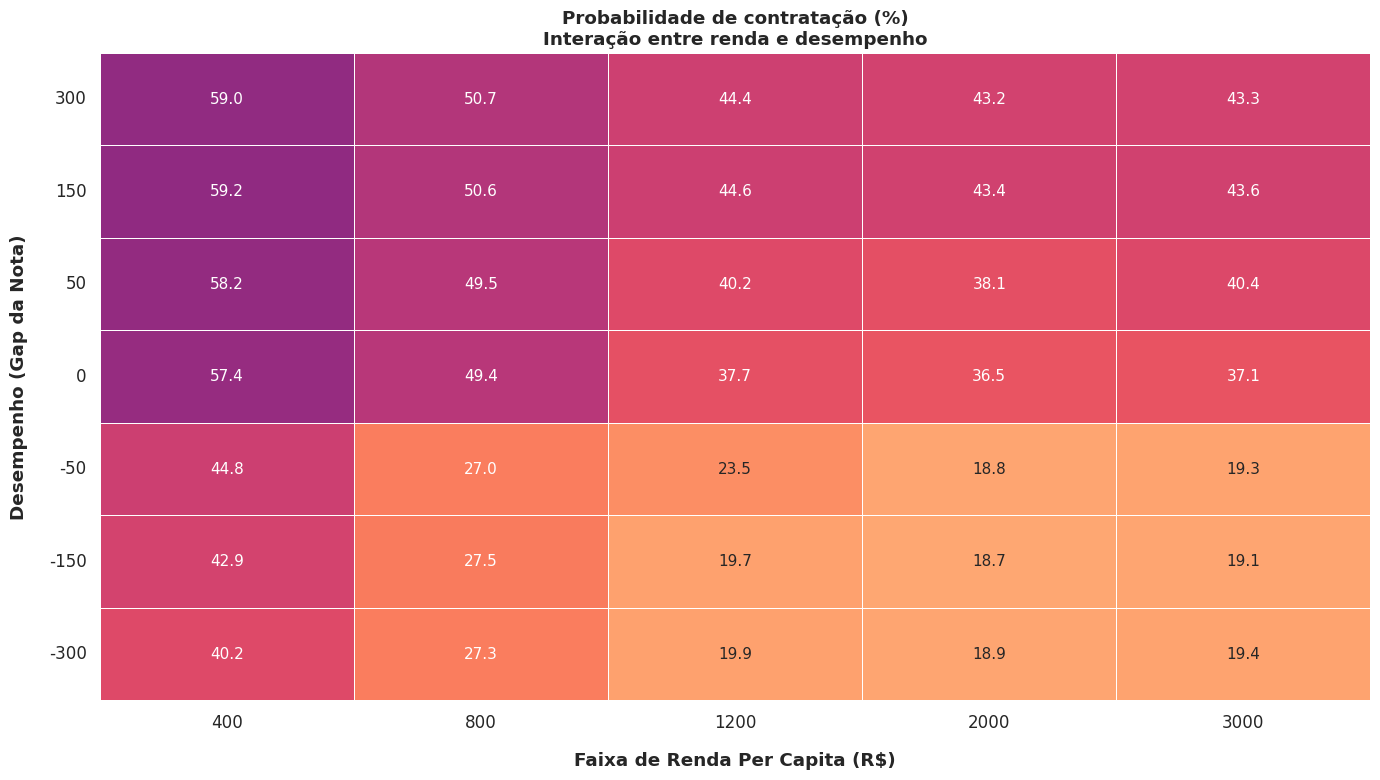


🧠 INTERPRETAÇÃO COMPLETA — RANDOM FOREST (ANÁLISE 017)

📊 IMPORTÂNCIA POR GRUPO (VISÃO LIMPA):
grupo
renda_per_capita    0.225565
subarea             0.180546
renda_gap           0.140621
gap                 0.097785
nota_corte_gp       0.072514
conceito            0.058550
idade               0.057457
regiao              0.041864
escola_publica      0.037231
instituicao         0.033513
Name: importancia, dtype: float64

🔎 FOCO NAS VARIÁVEIS-CHAVE:
 - renda_per_capita: 0.2256
 - gap:              0.0978
 - renda_gap:        0.1406

📌 INTERPRETAÇÃO DAS IMPORTÂNCIAS:

- A Random Forest NÃO usa coeficientes como a regressão.
- Ela aprende regras (árvores).

👉 A importância mede:
quanto cada variável ajudou a reduzir erro no modelo.


🔥 PRINCIPAL DRIVER: RENDA

📊 LEITURA ECONÔMICA DO MODELO:

O modelo está aprendendo padrões do tipo:

- renda alta + nota alta → maior probabilidade
- renda baixa + nota baixa → menor probabilidade
- nota pode compensar renda baixa
- renda pode suavizar not

In [ ]:
# RANDOM FOREST — classificação binária
# Base inteira 2019 a 2021
# Objetivo: captar não linearidade e interação entre renda_per_capita e gap

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)
from sklearn.inspection import PartialDependenceDisplay
from sklearn.tree import plot_tree, export_text
from IPython.display import display
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from constantes import (
    pasta_data_05_processed_analise_017_X_treino, 
    pasta_data_05_processed_analise_017_y_treino,
    pasta_data_04_load_inscritos
)

# =========================================================
# 1) CARREGAR DADOS
# =========================================================
import pandas as pd
from constantes import pasta_data_04_load_inscritos,pasta_data_05_processed_analise_017
from sklearn.linear_model import LogisticRegression

# Configuração de visualização
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# 1. CARREGAR OS DADOS
df_base = pd.read_parquet(str(pasta_data_04_load_inscritos))

# 2. CRIAR VARIÁVEIS NOVAS (Vetorizado, muito mais rápido)
df_base['gap'] = df_base['media_enem'] - df_base['nota_corte_gp']

def idade(x):
    try:
        return 2026 - int(str(x).split('/')[-1])
    except:
        return None

df_base['idade'] = df_base['data_nascimento'].apply(idade)



print('total de linhas de apenas:', df_base.shape)



print('-'*60)
print('qtde de inscritos:')
display(df_base.groupby('situacao_fies',as_index=False).size().rename(columns={'size':'qtde_inscritos'}))#type: ignore





# 3. DUMIZAR VARIÁVEIS CATEGÓRICAS
# Isso cria as colunas 0 e 1 e JÁ EXCLUI a 'nome_cine_area_geral' original
df = pd.get_dummies(df_base, columns=['beneficiado_creduc_fies','modalidade_fies','subarea_conhecimento','regiao_morar','natureza_juridica_mantenedora','etnia_cor','turno','ensino_medio_escola_publica','conceito_curso_gp','concluiu_curso_superior',], drop_first=True)

# 4. FILTRAR A BASE DE DADOS
contratados = ['CONTRATADA']
nao_contratados = ['NÃO CONTRATADO']

filtro = df['situacao_fies'].isin(contratados + nao_contratados)
df = df[filtro].copy()

# 5. CRIAR A VARIÁVEL ALVO (Y) BINÁRIA
df['contratado'] = df['situacao_fies'].apply(lambda x: 1 if x in contratados else 0)


# 6. PESCAR AS COLUNAS DUMMIES
# O Python procura e guarda apenas as colunas que começam com esse nome
colunas_dummies_turno = [col for col in df.columns if col.startswith('turno_')]

colunas_dummies_ensino_medio_escola_publica = [col for col in df.columns if col.startswith('ensino_medio_escola_publica_')]
colunas_dummies_etnia = [col for col in df.columns if col.startswith('etnia_cor_')]
colunas_dummies_cine = [col for col in df.columns if col.startswith('subarea_conhecimento_')]
colunas_dummies_regiao = [col for col in df.columns if col.startswith('regiao_morar_')]
colunas_dummies_natureza = [col for col in df.columns if col.startswith('natureza_juridica_mantenedora_')]
colunas_dummies_conceito_curso = [col for col in df.columns if col.startswith('conceito_curso_gp')]
colunas_dummies_conceito_concluiu_curso_superior = [col for col in df.columns if col.startswith('concluiu_curso_superior')]
colunas_dummies_conceito_concluiu_modfies = [col for col in df.columns if col.startswith('modalidade_fies')]
colunas_dummies_conceito_concluiu_BENEFcreduc = [col for col in df.columns if col.startswith('beneficiado_creduc_fies')]






# 9. CRIAR A LISTA EXATA DE FEATURES
# Juntamos as variáveis que você escolheu com as dummies
df['renda_gap']=df['renda_per_capita'] * df['gap']


features_exatas = ['renda_per_capita', 'gap','idade','nota_corte_gp','renda_gap']+ colunas_dummies_conceito_concluiu_BENEFcreduc + colunas_dummies_conceito_concluiu_modfies  + colunas_dummies_conceito_concluiu_curso_superior + colunas_dummies_conceito_curso + colunas_dummies_cine + colunas_dummies_regiao + colunas_dummies_natureza + colunas_dummies_etnia + colunas_dummies_turno + colunas_dummies_ensino_medio_escola_publica



# Faz o Raio-X apenas nas colunas que vão pro modelo
print("--- Quantidade de NaNs por coluna ---")
print(df[features_exatas].isna().sum())

# Isso garante que se o aluno sumir, ele some das duas listas
df_limpo = df.dropna(subset=features_exatas).copy()




df_treino = df_limpo
df_teste = df_limpo


# 8. SEPARAR O X E O Y
# O X recebe ESTRITAMENTE as colunas da sua lista branca
X = df_treino[features_exatas]

# O Y recebe a sua resposta
Y = df_treino['contratado']



X_teste = df_teste[features_exatas]

# O Y recebe a sua resposta
Y_teste= df_teste['contratado']


print('coluna x linha do X com NaN inclusos:',X.shape)

print('coluna x linha do X sem NaN inclusos:',X.shape)




print('-'*60)
print(f"Registros de Treino: {len(X):,}")
print(f"Registros de Teste: {len(X_teste):,}")






X_treino = X.copy()
Y_treino = Y.copy()

# usando a base inteira na avaliação
X_teste = X_treino.copy()
y_teste = Y_treino.copy()

# =========================================================
# 2) TREINAR MODELO
# =========================================================

max_depth = 42

modelo = RandomForestClassifier(
    max_depth=max_depth,
    n_estimators=1000,
    n_jobs=-1,
    class_weight='balanced',
    random_state=42,
    min_samples_leaf=125,
    max_features='sqrt'
)

modelo.fit(X_treino, Y_treino)

print("Modelo RandomForest treinado com sucesso.")

# =========================================================
# 3) VISUALIZAR UMA ÁRVORE DA FLORESTA (OPCIONAL)
# =========================================================

visualizar_arvore = 'nao'

if visualizar_arvore == 'sim':
    arvore = modelo.estimators_[0]

    plt.figure(figsize=(40, 20))
    plot_tree(
        arvore,
        feature_names=list(X_treino.columns),
        class_names=['Não Contratado', 'Contratado'],
        filled=True,
        rounded=True,
        fontsize=8,
        max_depth=3
    )
    plt.show()

    regras_arvore = export_text(
        arvore,
        feature_names=list(X_treino.columns),
        max_depth=3
    )
    print(regras_arvore)

# =========================================================
# 4) AVALIAÇÃO NA MESMA BASE
# =========================================================

y_probs = modelo.predict_proba(X_teste)[:, 1]

fpr, tpr, thresholds = roc_curve(y_teste, y_probs)
melhor_indice = (tpr - fpr).argmax()
threshold = thresholds[melhor_indice]
corte = threshold

print("corte:", corte)

y_predict = (y_probs >= threshold).astype(int)

acuracia = accuracy_score(y_teste, y_predict)
roc = roc_auc_score(y_teste, y_probs)

print(f"Acurácia da RandomForest: {acuracia:.4f}")
print("=== Relatório de Classificação ===")
print(classification_report(y_teste, y_predict))
print("roc:", roc)

matriz = confusion_matrix(y_teste, y_predict)

plt.figure(figsize=(6, 6))
sns.heatmap(matriz, annot=True, fmt='d', cmap='Oranges')
plt.title("Matriz de Confusão - RandomForest")
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.show()

print(f"Taxa prevista pelo modelo: {y_predict.mean():.3f}")
print(f"Taxa real na base: {y_teste.mean():.3f}")

# =========================================================
# 5) IMPORTÂNCIA DAS VARIÁVEIS
# =========================================================

df_importancias = pd.DataFrame({
    'Variavel': X_treino.columns,
    'Importancia': modelo.feature_importances_
}).sort_values(by='Importancia', ascending=False).reset_index(drop=True)

filtro = df_importancias['Importancia'] > 0

print("Top variáveis mais importantes:")
display(df_importancias[filtro].head(30))

print("Todas as importâncias:")
display(df_importancias)

plt.figure(figsize=(10, 8))
top20 = df_importancias.head(20).sort_values("Importancia")
plt.barh(top20["Variavel"], top20["Importancia"])
plt.title("Top 20 variáveis mais importantes")
plt.xlabel("Importância")
plt.ylabel("Variável")
plt.tight_layout()
plt.show()

# =========================================================
# 6) LEITURA DE INTERAÇÃO RENDA × GAP
# =========================================================

def analise_real_renda_gap_rf(modelo, X_ref):
    from pathlib import Path
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns

    # ==============================================================================
    # 1. CONFIGURAÇÕES (PADRÃO VISUAL)
    # ==============================================================================

    sns.set_theme(style="white", font_scale=1.1)

    pasta_figuras = Path('reports/figures/analise_017').resolve()
    pasta_figuras.mkdir(parents=True, exist_ok=True)

    # ==============================================================================
    # 2. GRID CONTROLADO (INTERPRETÁVEL)
    # ==============================================================================

    rendas = [400, 800, 1200, 2000, 3000]
    gaps = [-300, -150, -50, 0, 50, 150, 300]

    valores_medios = X_ref.mean(numeric_only=True)
    mediana_idade = X_ref['idade'].median()
    mediana_nota_corte = X_ref['nota_corte_gp'].median()

    linhas = []

    for renda in rendas:
        for gap in gaps:

            linha = {}

            for col in X_ref.columns:
                if col == 'renda_per_capita':
                    linha[col] = renda
                elif col == 'gap':
                    linha[col] = gap
                elif col == 'renda_gap':
                    linha[col] = renda * gap
                elif col == 'idade':
                    linha[col] = mediana_idade
                elif col == 'nota_corte_gp':
                    linha[col] = mediana_nota_corte
                else:
                    linha[col] = valores_medios.get(col, 0)

            linhas.append(linha)

    df_real = pd.DataFrame(linhas).reindex(columns=X_ref.columns, fill_value=0)

    # ==============================================================================
    # 3. PREDIÇÃO
    # ==============================================================================

    probs = modelo.predict_proba(df_real)[:, 1]
    df_real['prob'] = probs * 100  # 🔥 PADRÃO EM %

    # ==============================================================================
    # 4. CURVAS — IMPACTO DA NOTA DEPENDENDO DA RENDA
    # ==============================================================================

    print("\n[INFO] Gráfico 1: impacto da NOTA dependendo da RENDA")
    print("[INFO] Cada linha fixa uma renda e mostra como a probabilidade varia com o gap")
    print("[INFO] Linha azul (0.5 = 50%) é o limiar de decisão do modelo")

    plt.figure(figsize=(12, 7))

    for renda in rendas:
        subset = df_real[df_real['renda_per_capita'] == renda].sort_values('gap')

        plt.plot(
            subset['gap'],
            subset['prob'],
            marker='o',
            label=f'R$ {renda}'
        )

    plt.axhline(50, color='blue', linestyle='--', label='Limiar (50%)')

    plt.xlabel('Diferença para nota de corte (pontos)', fontweight='bold')
    plt.ylabel('Probabilidade de contratação (%)', fontweight='bold')
    plt.title('Impacto da nota dependendo da renda', fontweight='bold')

    plt.legend(title='Renda')
    plt.tight_layout()
    plt.savefig(pasta_figuras / 'rf_curvas_nota_por_renda.png', dpi=300, bbox_inches='tight')
    plt.show()

    # ==============================================================================
    # 5. CURVAS — IMPACTO DA RENDA DEPENDENDO DA NOTA
    # ==============================================================================

    print("\n[INFO] Gráfico 2: impacto da RENDA dependendo da NOTA")
    print("[INFO] Cada linha fixa um gap e mostra como a probabilidade varia com a renda")

    plt.figure(figsize=(12, 7))

    for gap in gaps:
        subset = df_real[df_real['gap'] == gap].sort_values('renda_per_capita')

        plt.plot(
            subset['renda_per_capita'],
            subset['prob'],
            marker='o',
            label=f'Gap {gap}'
        )

    plt.axhline(50, color='blue', linestyle='--', label='Limiar (50%)')

    plt.xlabel('Renda per capita (R$)', fontweight='bold')
    plt.ylabel('Probabilidade de contratação (%)', fontweight='bold')
    plt.title('Impacto da renda dependendo da nota', fontweight='bold')

    plt.legend(title='Gap')
    plt.tight_layout()
    plt.savefig(pasta_figuras / 'rf_curvas_renda_por_nota.png', dpi=300, bbox_inches='tight')
    plt.show()

    # ==============================================================================
    # 6. HEATMAP — PADRÃO ABNT (RENDA × NOTA)
    # ==============================================================================

    print("\n[INFO] Heatmap: visão consolidada renda × nota")

    ordem_gap = gaps[::-1]  # 🔥 alto desempenho em cima

    matriz = df_real.pivot(
        index='gap',
        columns='renda_per_capita',
        values='prob'
    ).reindex(index=ordem_gap, columns=rendas)

    plt.figure(figsize=(14, 8))

    sns.heatmap(
        matriz,
        annot=True,
        fmt=".1f",
        cmap="magma_r",
        vmin=0,
        vmax=100,
        linewidths=0.5,
        linecolor='white',
        annot_kws={"size": 11},
        cbar=False
    )

    plt.ylabel('Desempenho (Gap da Nota)', fontweight='bold', labelpad=15)
    plt.xlabel('Faixa de Renda Per Capita (R$)', fontweight='bold', labelpad=15)

    plt.xticks(rotation=0)
    plt.yticks(rotation=0)

    plt.title(
        'Probabilidade de contratação (%)\nInteração entre renda e desempenho',
        fontweight='bold'
    )

    plt.tight_layout()
    plt.savefig(pasta_figuras / 'rf_heatmap_renda_nota.png', dpi=300, bbox_inches='tight')
    plt.show()

analise_real_renda_gap_rf(modelo, X_treino)


# =========================================================
# 8) INTERPRETAÇÃO COMPLETA DO MODELO (PRINT EXPLICATIVO)
# =========================================================

def interpretacao_modelo_random_forest(modelo, X):

    import pandas as pd
    import numpy as np

    print("\n" + "="*80)
    print("🧠 INTERPRETAÇÃO COMPLETA — RANDOM FOREST (ANÁLISE 017)")
    print("="*80)

    # =====================================================
    # 1. IMPORTÂNCIAS
    # =====================================================

    df_imp = pd.DataFrame({
        'variavel': X.columns,
        'importancia': modelo.feature_importances_
    }).sort_values(by='importancia', ascending=False)

    # =====================================================
    # 🔥 2. AGRUPAMENTO INTELIGENTE (ANTI-DUMMY SPAM)
    # =====================================================

    def grupo(var):
        if var.startswith('subarea_conhecimento'):
            return 'subarea'
        elif var.startswith('regiao_morar'):
            return 'regiao'
        elif var.startswith('etnia_cor'):
            return 'etnia'
        elif var.startswith('turno'):
            return 'turno'
        elif var.startswith('ensino_medio_escola_publica'):
            return 'escola_publica'
        elif var.startswith('natureza_juridica'):
            return 'instituicao'
        elif var.startswith('modalidade_fies'):
            return 'modalidade'
        elif var.startswith('beneficiado_creduc_fies'):
            return 'creduc'
        elif var.startswith('conceito_curso_gp'):
            return 'conceito'
        elif var.startswith('concluiu_curso_superior'):
            return 'formacao'
        else:
            return var  # renda, gap, renda_gap, idade etc

    df_imp['grupo'] = df_imp['variavel'].apply(grupo)

    df_grupo = df_imp.groupby('grupo')['importancia'].sum().sort_values(ascending=False)

    print("\n📊 IMPORTÂNCIA POR GRUPO (VISÃO LIMPA):")
    print(df_grupo.head(10))

    # =====================================================
    # 3. FOCO NAS VARIÁVEIS-CHAVE
    # =====================================================

    imp_renda = df_imp.loc[df_imp['variavel'] == 'renda_per_capita', 'importancia'].sum()
    imp_gap = df_imp.loc[df_imp['variavel'] == 'gap', 'importancia'].sum()
    imp_inter = df_imp.loc[df_imp['variavel'] == 'renda_gap', 'importancia'].sum()

    print("\n🔎 FOCO NAS VARIÁVEIS-CHAVE:")
    print(f" - renda_per_capita: {imp_renda:.4f}")
    print(f" - gap:              {imp_gap:.4f}")
    print(f" - renda_gap:        {imp_inter:.4f}")

    # =====================================================
    # 4. INTERPRETAÇÃO
    # =====================================================

    print("\n📌 INTERPRETAÇÃO DAS IMPORTÂNCIAS:")

    print("""
- A Random Forest NÃO usa coeficientes como a regressão.
- Ela aprende regras (árvores).

👉 A importância mede:
quanto cada variável ajudou a reduzir erro no modelo.
""")

    # driver principal
    if imp_inter > imp_renda and imp_inter > imp_gap:
        driver = "INTERAÇÃO (renda × gap)"
    elif imp_gap > imp_renda:
        driver = "DESEMPENHO (gap)"
    else:
        driver = "RENDA"

    print(f"\n🔥 PRINCIPAL DRIVER: {driver}")

    # =====================================================
    # 5. LEITURA ECONÔMICA
    # =====================================================

    print("\n📊 LEITURA ECONÔMICA DO MODELO:")

    print("""
O modelo está aprendendo padrões do tipo:

- renda alta + nota alta → maior probabilidade
- renda baixa + nota baixa → menor probabilidade
- nota pode compensar renda baixa
- renda pode suavizar nota ruim

👉 Isso é interação + não-linearidade.
""")

    # =====================================================
    # 6. INTERPRETAÇÃO DOS GRÁFICOS
    # =====================================================

    print("\n📈 INTERPRETAÇÃO DOS GRÁFICOS:")

    print("""
CURVAS (nota vs renda):
- Cada linha = renda fixa
- Se linhas mudam → interação

CURVAS (renda vs nota):
- Cada linha = nível de desempenho
- Se não paralelas → interação

HEATMAP:
- Cada célula = probabilidade

Leitura:
- diagonal → interação forte
- vertical → nota domina
- horizontal → renda domina
""")

    # =====================================================
    # 7. COMPARAÇÃO COM LOGIT
    # =====================================================

    print("\n⚖️ RANDOM FOREST vs REGRESSÃO LOGÍSTICA:")

    print("""
LOGIT:
- linear
- coeficiente direto
- interação explícita (renda_gap)

RF:
- não linear
- interação automática
- captura regras reais mais complexas
""")

    # =====================================================
    # 8. CONCLUSÃO
    # =====================================================

    print("\n🏁 CONCLUSÃO FINAL:")

    print(f"""
- renda: {imp_renda:.4f}
- gap: {imp_gap:.4f}
- interação: {imp_inter:.4f}

👉 O modelo mostra:

✔ renda importa
✔ desempenho importa
✔ combinação dos dois importa

👉 Ou seja:
o sistema NÃO é linear

👉 decisão depende do contexto do aluno
(renda + desempenho juntos)
""")

    print("="*80)

# EXECUTAR
interpretacao_modelo_random_forest(modelo, X_treino)

# =========================================================
# 7) SALVAR MODELO (OPCIONAL)
# =========================================================
# import joblib
# from constantes import pasta_modelo_analise_017
# joblib.dump(modelo, str(pasta_modelo_analise_017))
# print(f"Modelo salvo em: {str(pasta_modelo_analise_017)}")